# Matplotlib Interactivity

We have seen how we can achieve some interactivity by running Matplotlib within a notebook environment using `ipywidgets` and `ipympl`. As mentioned interactivity can also be achieved without relying on the notebook environment but instead relying on matplotlib alone.

Within Matplotlib, there are two ways in which you can achieve interactivity:
1. Using matplotlib.widgets: `Slider`, `Button`, `CheckButtons`, `SpanSelector`, `LassoSelector`, etc. They have their own internal event handling already wired up. You just connect your callback to their high-level signal.
2. Using `.mpl_connect()' (through `fig.canvas`). Raw event handling where you connect directly to low-level mouse and keyboard events on the canvas. You get a bare **event object** and have to extract and interpret everything yourself

## Maplotlib widgets

Once again Matplotlib interaction is built on a simple idea: *Something happens* → *a function runs* → *the plot updates.*

The mental model is always the same:
1. Create a figure and axes
2. Plot something and **keep a reference** to the plot object
3. Create a widget (or connect an event)
4. Write a callback that *modifies* the existing plot object
5. Call `draw_idle()` inside the callback

All Maplotlib widgets need an **axes object** to sit in. This is often achieved by leaving space for the widget/s ax/es by adjusting the main plot axes using `fig.subplots_adjust()`.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
import matplotlib.path as mpath
import numpy as np

Let's explore a few examples.

### Slider

In [2]:
def moving_average(data, w):
    """Simple uniform moving average with window width w"""
    kernel = np.ones(w) / w
    return np.convolve(data, kernel, mode='same')

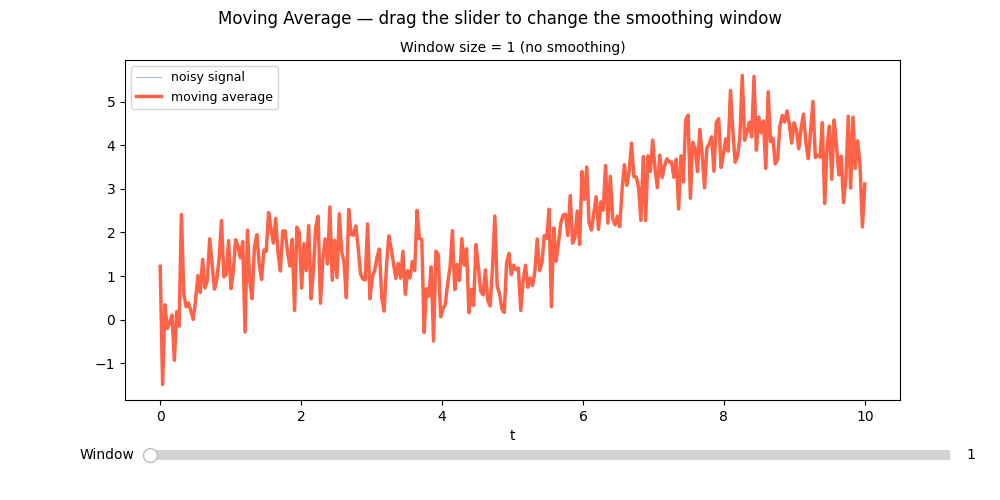

In [3]:
%matplotlib widget

# Data 
rng = np.random.default_rng(3)
n = 300
t = np.linspace(0, 10, n)
pattern = np.sin(t) + 0.4 * t 
noise = rng.normal(0, 0.6, n)
noisy = pattern + noise

# Create Figure and Axes
fig, ax_main = plt.subplots(figsize=(10, 5))
fig.subplots_adjust(bottom=0.20) # Leave space in the bottom for slider widget axes
fig.suptitle('Moving Average — drag the slider to change the smoothing window',
             size= 12)

# Create Slider widget and its axes
ax_slider = fig.add_axes([0.15, 0.07, 0.8, 0.04])
slider = mwidgets.Slider(ax_slider, 'Window', valmin=1, valmax=80, valinit=1, valstep=1)

# plot series
ax_main.plot(t, noisy, color='steelblue', lw=0.8, alpha=0.5, label='noisy signal')

# plot smooth line after passing a moving average window
smooth_line, = ax_main.plot(t, moving_average(noisy, 1), color='tomato',
                        lw=2.5, label='moving average')
ax_main.set_xlabel('t')
ax_main.legend(loc='upper left', fontsize=9)
ax_main.set_title('Window size = 1 (no smoothing)', size=10)

# Callback function
def update(val):
    w = int(slider.val)
    smooth_line.set_ydata(moving_average(noisy,w))
    ax_main.set_title(f'Window size= {w}', size=10)
    fig.canvas.draw_idle()

# Link observer with callback (update) functions
slider.on_changed(update)

plt.show()

### Buttons

Button callbacks receive an `event` object (a mouse event), but you typically ignore it and just respond to the click itself.

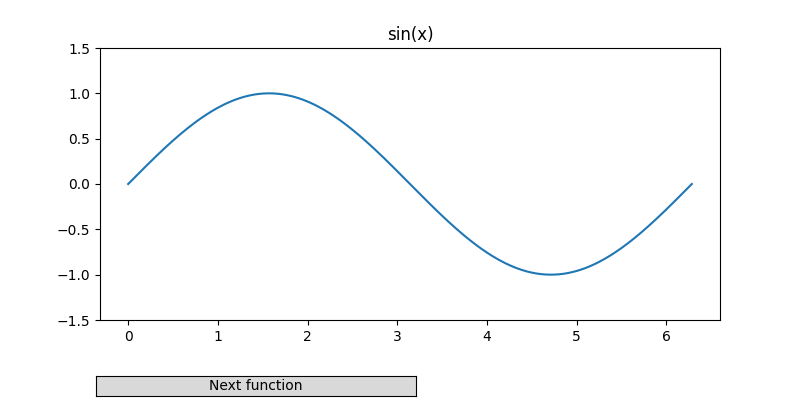

In [4]:
%matplotlib widget

# create data
x = np.linspace(0, 2 * np.pi, 500)
functions = [np.sin, np.cos, lambda x: np.sin(x) * np.cos(2 * x)]
labels     = ['sin(x)', 'cos(x)', 'sin(x)·cos(2x)']
idx = [0]   # mutable container to hold state across calls

# create plot
fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(bottom=0.2)
line, = ax.plot(x, functions[0](x)) # capture line artist to be changed later
ax.set_ylim(-1.5, 1.5)
ax.set_title(labels[0])

# create widget
ax_btn = fig.add_axes([0.12, 0.01, 0.4, 0.05])
btn = mwidgets.Button(ax_btn, 'Next function')

# call back function
def on_click(event):
    idx[0] = (idx[0] + 1) % len (functions) # rotates function
    line.set_ydata(functions[idx[0]](x))
    ax.set_title(labels[idx[0]])
    fig.canvas.draw_idle()

# attach callback to observer
btn.on_clicked(on_click)

plt.show() 

### Checkboxes
Can you make the button (= axes) to be in the center, a bit smaller???

Here is another example using checkboxes,

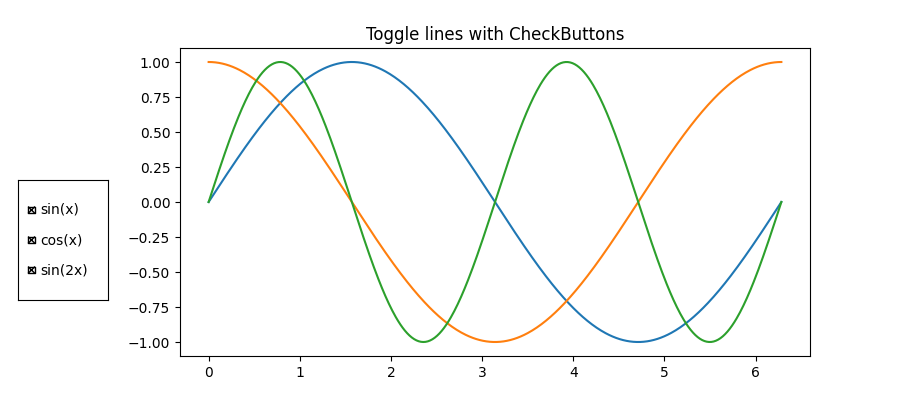

In [5]:
%matplotlib widget

# data
x = np.linspace(0, 2 * np.pi, 500)

# create plot
fig, ax = plt.subplots(figsize=(9, 4))
fig.subplots_adjust(left=0.2)
ax.set_title('Toggle lines with CheckButtons')


lines = {
    'sin(x)':   ax.plot(x, np.sin(x),    label='sin(x)')[0], # we need [0] so that we get access to the line itself
    'cos(x)':   ax.plot(x, np.cos(x),    label='cos(x)')[0],
    'sin(2x)':  ax.plot(x, np.sin(2*x),  label='sin(2x)')[0],
}

# create widget
ax_check = fig.add_axes([0.02, 0.25, 0.1, 0.3])
check = mwidgets.CheckButtons(ax_check, list(lines.keys()), [True, True, True])

# define callback
def on_toggle(label):
    lines[label].set_visible(not lines[label].get_visible())
    fig.canvas.draw_idle()

# attach callback to observer
check.on_clicked(on_toggle)

plt.show()

### Lasso Selector

Next, we explore a more interesting widget `LassoSelector` that allows us to draw an irregular shape to select points.

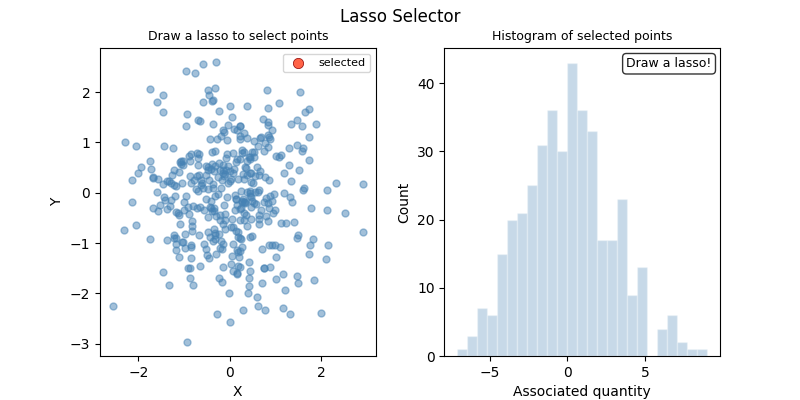

In [13]:
import matplotlib.path as mpath

# Create Data
rng = np.random.default_rng(42)
N = 400
x = rng.normal(0, 1, N)
y = rng.normal(0, 1, N)
quantity = 2 * x - 1.5 * y + rng.normal(0, 1.5, N)

# Stack into (N, 2) array once — reused in every lasso call
xy = np.c_[x, y]

# Create plot layout
fig, (ax_sc, ax_hist) = plt.subplots(1, 2, figsize=(8, 4))
fig.subplots_adjust(wspace=0.25)
fig.suptitle('Lasso Selector', fontsize=12)

# Plot scatter points
ax_sc.scatter(x, y, c='steelblue', s=25, alpha=0.5, zorder=2)
ax_sc.set_xlabel('X')
ax_sc.set_ylabel('Y')
ax_sc.set_title('Draw a lasso to select points', fontsize=9)

# Plot of selected points (initially emply)
selected_sc = ax_sc.scatter([], [], c='tomato', s=55, zorder=5,
                             edgecolors='darkred', linewidths=0.5,
                             label='selected')
ax_sc.legend(loc='upper right', fontsize=8)

# Histogram plot
ax_hist.set_xlabel('Associated quantity')
ax_hist.set_ylabel('Count')
ax_hist.set_title('Histogram of selected points', fontsize=9)

# Background histogram (all data)
_, bins, _ = ax_hist.hist(quantity, bins=25, color='steelblue',
                            edgecolor='white', alpha=0.3, label='all data')

count_text = ax_hist.text(0.97, 0.97, 'Draw a lasso!',
                           transform=ax_hist.transAxes,
                           ha='right', va='top', fontsize=9,
                           bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# Initializes tracker for histogram bars
sel_patches = [None]   # holds current selection histogram patches

def clear_selection_hist():
    if sel_patches[0] is not None:
        for p in sel_patches[0]:
            p.remove()
        sel_patches[0] = None

#  Denfine Lasso callback function
def on_lasso(verts):
    """
    Called when the user finishes drawing the lasso.

    `verts` is a list of (x, y) tuples tracing the drawn polygon.
    We turn it into a Path and ask which of our data points lie inside it.
    """
    # Build a matplotlib Path from the lasso vertices
    path = mpath.Path(verts)

    # Call contains_points() function of a path in order
    # to return returns a boolean array (one entry per point).
    # Points selected are True
    mask = path.contains_points(xy)
    indices = np.where(mask)[0] # Return the indices of points selected

    # any points selected?
    if len(indices) > 0: 
        selected_sc.set_offsets(xy[indices])
    else:
        # return empty 2D numpy if no selection
        selected_sc.set_offsets(np.empty((0, 2)))

    # Update histogram 
    clear_selection_hist()

    if len(indices) > 0:
        q_sel = quantity[indices] # Creates histogram of points selected
        _, _, patches = ax_hist.hist(q_sel, bins=bins,
                                      color='tomato', edgecolor='white',
                                      alpha=0.85, label='selected')
        sel_patches[0] = patches
        count_text.set_text(f'n = {len(indices)} selected\n'
                             f'mean = {q_sel.mean():.2f}\n'
                             f'std  = {q_sel.std():.2f}')
        ax_hist.set_title(f'Quantity — {len(indices)} selected points', fontsize=9)
        ax_hist.legend(fontsize=8)
    else:
        count_text.set_text('No points selected\nDraw a lasso!')
        ax_hist.set_title('Histogram of selected points')

    fig.canvas.draw_idle()

# attach callback to observer
lasso = mwidgets.LassoSelector(ax_sc, on_lasso, useblit=False)

plt.show()

### Span selector

A span selector allows us to span a rectangular selection area (could be horizontal or vertical) in order to select some data points.

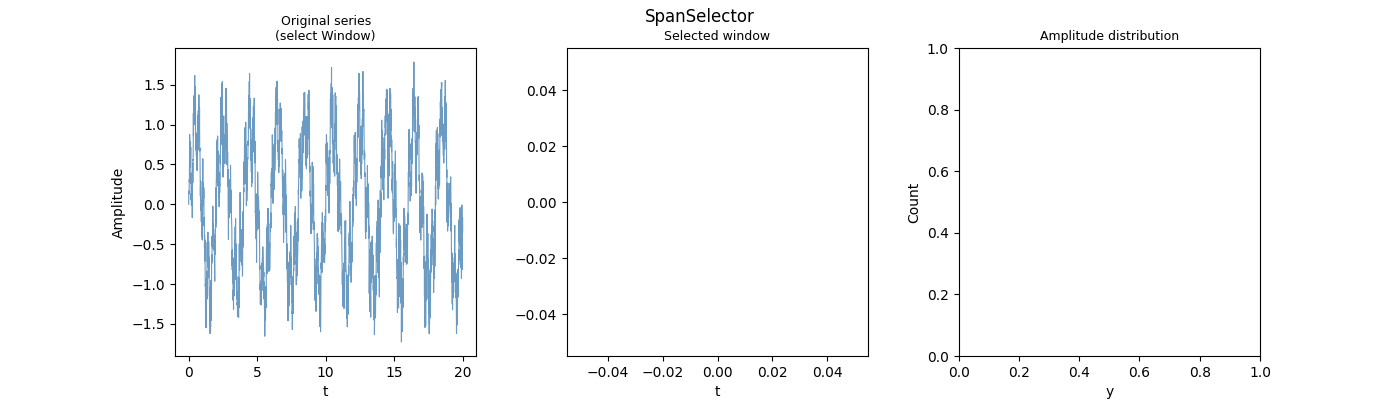

In [7]:
%matplotlib widget

# Create data
rng = np.random.default_rng(7)
t = np.linspace(0, 20, 2000)
# Signal with three distinct regimes
y = (np.sin(2 * np.pi * 0.5 * t) +
     0.4 * np.sin(2 * np.pi * 3 * t) +
     rng.normal(0, 0.2, len(t)))

fig, (ax_sig, ax_zoom, ax_hist) = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(wspace=0.3)
fig.suptitle('SpanSelector', fontsize=12)

# Plot original series 
ax_sig.plot(t, y, lw=0.8, color='steelblue', alpha=0.8)
ax_sig.set_title('Original series\n(select Window)', fontsize=9)
ax_sig.set_xlabel('t')
ax_sig.set_ylabel('Amplitude')

# Plot Zoomed area
line_zoom, = ax_zoom.plot([], [], lw=1.4, color='tomato')
ax_zoom.set_title('Selected window', fontsize=9)
ax_zoom.set_xlabel('t')

# Plot Histogram of amplitude
ax_hist.set_title('Amplitude distribution', fontsize=9)
ax_hist.set_xlabel('y')
ax_hist.set_ylabel('Count')

# Stats text box
stats_text = ax_hist.text(0.97, 0.97, '', transform=ax_hist.transAxes,
                           ha='right', va='top', fontsize=8,
                           bbox=dict(boxstyle='round', fc='white',
                                     edgecolor='gray', alpha=0.7))
# Initialize histogram patches
hist_patches = [None]

def on_select(vmin, vmax):
    if vmax - vmin < 0.05: # minimu size of window
        return

    mask = (t >= vmin) & (t <= vmax)
    t_sel = t[mask]
    y_sel = y[mask]

    # Update zoom plot
    line_zoom.set_data(t_sel, y_sel)
    ax_zoom.set_xlim(t_sel.min(), t_sel.max())
    ax_zoom.set_ylim(y_sel.min() - 0.15, y_sel.max() + 0.15)
    ax_zoom.set_title(f'Window  [{vmin:.1f}, {vmax:.1f}] - {len(y_sel)} samples', fontsize=9)

    # Update histogram
    if hist_patches[0] is not None:
        for p in hist_patches[0]:
            p.remove()
    _, _, patches = ax_hist.hist(y_sel, bins=30, color='tomato',
                                  edgecolor='white', alpha=0.85)
    hist_patches[0] = patches
    ax_hist.set_xlim(y.min() - 0.2, y.max() + 0.2)   # keep fixed x axis

    stats_text.set_text(
        f'mean  = {y_sel.mean():.3f}\n'
        f'std   = {y_sel.std():.3f}\n'
        f'min   = {y_sel.min():.3f}\n'
        f'max   = {y_sel.max():.3f}'
    )
    fig.canvas.draw_idle()

span = mwidgets.SpanSelector(ax_sig, on_select, 'horizontal', useblit=True,
                            props=dict(alpha=0.2, facecolor='orange'),
                             interactive=True,
                             drag_from_anywhere=True)
plt.show()

Could you change the code so that the area selected in othe original series axes changes color?

## Matplotlib Raw event handling (no widgets needed)

Matplotlib can react to certain events (mouse) without recourse to widgets. These are acchieved by connecting a callback function using `fig.canvas.mpl_connect(event_name, callback)`.

Here is a very simple example,

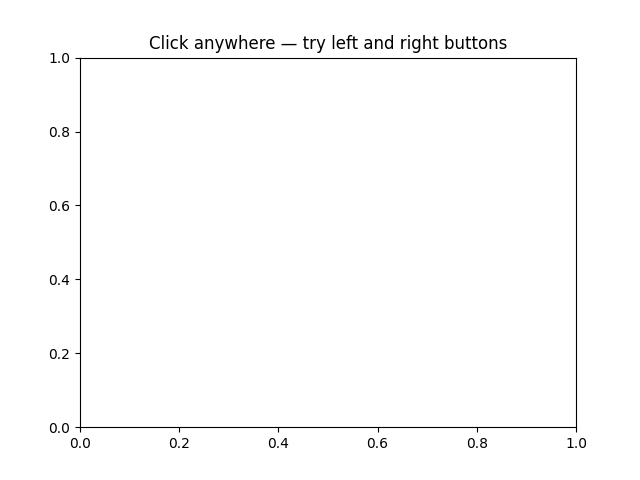

In [8]:
%matplotlib widget
fig, ax = plt.subplots()
ax.set_title('Click anywhere — try left and right buttons')

def on_click(event):
    if event.inaxes != ax:
        return
    if event.button == 1: #LEFT
        ax.scatter(event.xdata, event.ydata,  marker='o', color='b', s=40)
    elif event.button == 3: # RIGHT
        ax.scatter(event.xdata, event.ydata,  marker='s', color='r', s=40)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

## Picking

**Picking** is the mechanism that lets you click **on a plotted artist** (a line, a bar, a scatter point) and trigger a response. It differs from `button_press_event`, which fires anywhere on the figure. A pick event only fires when you click *on* a specific drawn object. To enable picking, you need to follow a few steps:


* **Step 1**. Enable picking on the artist

```python
line, = ax.plot(x, y, picker=True)   # any click on the line triggers
line, = ax.plot(x, y, picker=5)      # click within 5 display-points of the line triggers
sc   = ax.scatter(x, y, picker=True)
bars = ax.bar(cats, vals, picker=True)
```

```{note}
`picker=True` uses the default hit-test for the artist type. `picker=5` means fire if the mouse is within 5 display-points of the artist.
```

**Step 2**. Connect a callback to `'pick_event'` using `.mpl_connect('pick_event', on_pick)`

```python
fig.canvas.mpl_connect('pick_event', on_pick)
```

**Step 3**. Inspect the `event` object in the callback

| Attribute | What it contains |
|---|---|
| `event.artist` | The actual object that was clicked (`Line2D`, `Rectangle`, `PathCollection`, …) |
| `event.ind` | An **array of indices** into the data that were under the cursor (you may pick more than one artist) |
| `event.mouseevent` | The underlying mouse event (see next) |

Mouse events can be of different type 
| Event string | When it fires |
|---|---|
| `'button_press_event'` | mouse button pressed |
| `'button_release_event'` | mouse button released |
| `'motion_notify_event'` | mouse moved |
| `'scroll_event'` | the scroll wheel scrolled |

Inside the callback, the mouse `event` object contains the following information:
* `.xdata`, `.ydata`. Data coordinates.
* `.inaxes`. Axes that was under the cursor.
* `.button` The mounse button pressed (1: Right, 2: Middle, 3:Left).


Let's consider a basic example:  scatter with tooltip

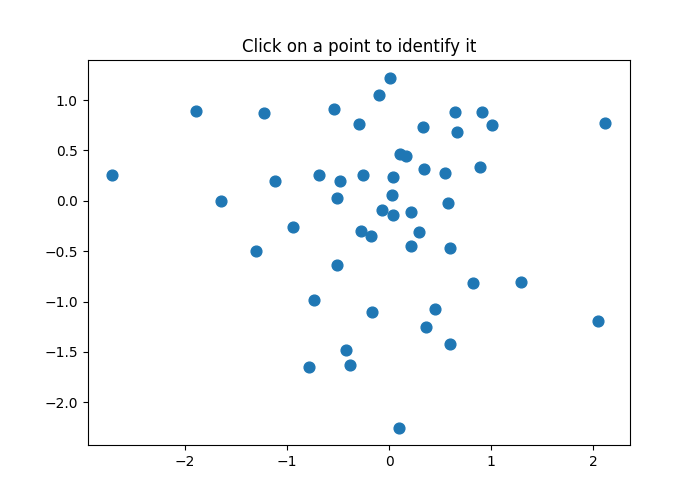

In [9]:
%matplotlib widget

# Create data
rng = np.random.default_rng(1)
x = rng.normal(0, 1, 50)
y = rng.normal(0, 1, 50)
names = [f'Point {i}' for i in range(50)]

# Create the plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Click on a point to identify it')

# picker=8 → click within 8 display-points of a dot fires the event
sc = ax.scatter(x, y, s=60, picker=8)

# Initiate the annotation without any coordinates at the moment
annot = ax.annotate('', xy=(0, 0), xytext=(15, 15),
                    textcoords='offset points',
                    bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'),
                    arrowprops=dict(arrowstyle='->'))
annot.set_visible(False)

def on_pick(event):
    if event.artist is not sc:
        return                        # ignore picks on other artists
    ind = event.ind[0]               # take first index if multiple overlap
    annot.xy = (x[ind], y[ind])
    annot.set_text(f'{names[ind]}\n({x[ind]:.2f}, {y[ind]:.2f})')
    annot.set_visible(True)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)
plt.show()

For a `Line2D`, `event.ind` contains all data-point indices near the click. It often contains multiple values when points are close together — take `ind[0]` for the closest.

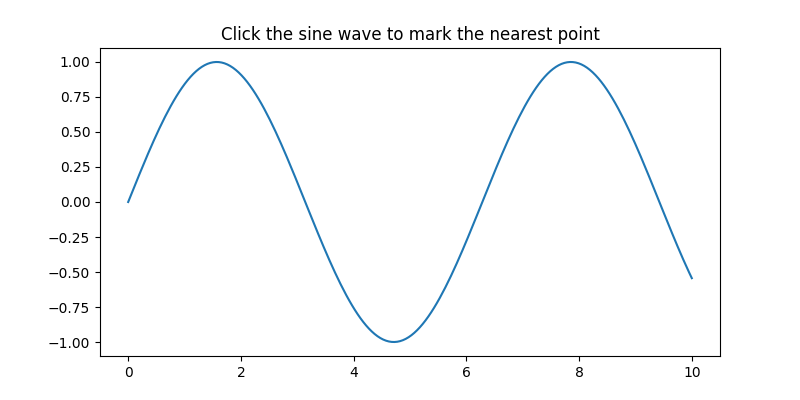

In [10]:
%matplotlib widget

# Create data
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Create plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title('Click the sine wave to mark the nearest point')
pick_radius = 5
line, = ax.plot(x, y, picker= pick_radius)           # 5-point tolerance

marker, = ax.plot([], [], 'ro', ms=10)    # red dot to show picked location

def on_pick(event):
    if event.artist is not line:
        return
    ind = event.ind[0]                    # closest point index
    marker.set_data([x[ind]], [y[ind]])
    ax.set_xlabel(f'Picked index {ind}:  x={x[ind]:.2f},  y={y[ind]:.2f}')
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)
plt.show()

Keep in mind the following

- **Multiple artists, multiple picks:** If several artists with `picker=True` overlap, multiple pick events fire — one per artist. Always guard with `if event.artist is not my_artist: return`.
- **`event.ind` can be multi-valued:** Always decide whether to take `ind[0]` or handle all of them.
- **Picking vs `button_press_event`:** Use picking when you care *which data element* was clicked. Use `button_press_event` when you care *where* on the axes the click landed.

In our final example, we click on a bar find out which datapoints are above/below a reference line


In [11]:
def draw_table(cat):
    """Remove old table (if any) and draw a new one for `cat`."""
    if current_table[0] is not None:
        current_table[0].remove()
        current_table[0] = None

    vals  = cat_data[cat]['values']
    items = cat_data[cat]['items']
    mean  = vals.mean()

    display_n = 10
    rows = []
    for i in range(display_n):
        direction = '▲' if vals[i] >= mean else '▼'
        rows.append([items[i], f'{vals[i]:.1f}', direction])

    tbl = ax_tbl.table(
        cellText=rows,
        colLabels=['Item', 'Value', '.vs. Mean'],
        colWidths=[0.20, 0.20, 0.20],
        loc='upper center',
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    # Style header row
    for col in range(3):
        cell = tbl[0, col]
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white')

    # Style data rows with alternating background and coloured arrows
    for row in range(1, display_n + 1):
        bg = '#EEF2FA' if row % 2 == 0 else 'white'
        for col in range(3):
            tbl[row, col].set_facecolor(bg)
        arrow_color = 'green' if rows[row - 1][2] == '▲' else 'tomato'
        tbl[row, 2].set_text_props(color=arrow_color, fontweight='bold')

    ax_tbl.set_title(
        f'Showing first {display_n} of {len(vals)} records for "{cat}"'
        f'   |   mean = {mean:.1f}   std = {vals.std():.1f}',
        fontsize=9, loc='left', pad=6, color='#333333'
    )
    current_table[0] = tbl

In [12]:
%matplotlib widget

# Create the data
rng = np.random.default_rng(0)
categories = ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']

cat_data = {}
for i, cat in enumerate(categories):
    n = 40
    vals = rng.normal(loc=50 + i * 7, scale=10, size=n).round(1)
    cat_data[cat] = {'values': vals, 'items': [f'Item-{j:03d}' for j in range(n)]}

means = [cat_data[c]['values'].mean() for c in categories]

# Create Figure layout
fig = plt.figure(figsize=(11, 7))
ax_bar = fig.add_axes([0.08, 0.44, 0.88, 0.52])   # bar chart (top)
ax_tbl = fig.add_axes([0.08, 0.02, 0.88, 0.35])   # table area (bottom)
ax_tbl.axis('off')

# Plot Bar chart
COLOR_DEFAULT  = 'lightblue'
COLOR_SELECTED = 'orange'

bars = ax_bar.bar(categories, means,
                  color=COLOR_DEFAULT, edgecolor='white', linewidth=1,
                  picker=True)           # <-- enables picking on each bar
ax_bar.set_ylabel('Mean value')
ax_bar.set_ylim(0, 110)
ax_bar.set_title('Click bar to inspect data', fontsize= 12)

# Plot mean line
ax_bar.axhline(np.mean(means), color='gray', lw=2, ls='--', alpha= 0.6, picker= 3)

# Value label that floats above the selected bar
val_label = ax_bar.text(0, 0, '', ha='center', va='bottom', fontsize=10,
                         fontweight='bold', color=COLOR_SELECTED)

# Initialize table
current_table = [None]   # list so we can mutate it inside the closure

# Define call back functions
def on_pick(event):
    if ##   # guard against stray pick events
        return

    clicked_bar = event.artist # returns the actual bar (= Rectangle artist)
    clicked_idx = ##
                        # ^ this return the index of the bar clicked on
    cat = categories[clicked_idx]

    # Reset all bar colours, highlight selected
    for bar in bars:
        bar.set_facecolor(COLOR_DEFAULT)
    clicked_bar.set_facecolor(COLOR_SELECTED)

    # Move the floating value label above the selected bar
    val_label.set_position((clicked_idx, means[clicked_idx] + 1.5))
    val_label.set_text(f'{means[clicked_idx]:.1f}')

    draw_table(cat)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)

# Instruction hint (shown until user clicks)
ax_bar.text(0.5, 0.70, 'Click a bar', transform=ax_bar.transAxes,
            ha='center', va='center', fontsize=16,
            color='gray', fontweight='bold')

plt.show()

SyntaxError: invalid syntax (3303707400.py, line 44)

New version.

In [ ]:
def draw_table(cat, ref_y):
    """Remove old table (if any) and draw a new one for category `cat`."""
    # Clear prior table
    if current_table[0] is not None:
        current_table[0].remove()
        current_table[0] = None

    vals  = cat_data[cat]['values']
    items = cat_data[cat]['items']
    cat_mean = float(vals.mean())

    display_n = min(10, len(vals))
    rows = []
    for i in range(display_n):
        direction = '▲' if vals[i] >= ref_y else '▼'
        rows.append([items[i], f'{vals[i]:.1f}', direction])

    tbl = ax_tbl.table(
        cellText=rows,
        colLabels=['Item', 'Value', 'vs. Ref'],
        colWidths=[0.20, 0.20, 0.20],
        loc='upper center',
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    # Style header
    for c in range(3):
        cell = tbl[0, c]
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white')

    # Alternate row backgrounds + coloured arrows
    for r in range(1, display_n + 1):
        bg = '#EEF2FA' if r % 2 == 0 else 'white'
        for c in range(3):
            tbl[r, c].set_facecolor(bg)
        arrow_color = 'green' if rows[r - 1][2] == '▲' else 'tomato'
        tbl[r, 2].set_text_props(color=arrow_color, fontweight='bold')

    ax_tbl.set_title(
        (f'Showing first {display_n} of {len(vals)} records for "{cat}"'
         f'   |   category mean = {cat_mean:.1f}   std = {vals.std():.1f}'
         f'   |   reference = {ref_y:.1f}'),
        fontsize=9, loc='left', pad=6, color='#333333'
    )

    current_table[0] = tbl

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Create Data
rng = np.random.default_rng(0)
categories = ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']

cat_data = {}
for i, cat in enumerate(categories):
    n = 40
    vals = rng.normal(loc=50 + i * 7, scale=10, size=n).round(1)
    cat_data[cat] = {
        'values': vals,
        'items': [f'Item-{j:03d}' for j in range(n)]
    }

means = [cat_data[c]['values'].mean() for c in categories]

# Figure layout 
fig = plt.figure(figsize=(11, 7))
ax_bar = fig.add_axes([0.08, 0.44, 0.88, 0.52])   # bar chart (top)
ax_tbl = fig.add_axes([0.08, 0.02, 0.88, 0.35])   # table area (bottom)
ax_tbl.axis('off')

# Plot Bar
COLOR_DEFAULT  = 'lightblue'
COLOR_SELECTED = 'orange'
bars = ax_bar.bar(
    categories, means,
    color=COLOR_DEFAULT, edgecolor='white', linewidth=1
)
ax_bar.set_ylim(0, 110)
ax_bar.set_title('Click a bar to inspect data; drag the dashed line to change reference', fontsize=12)

# Floating value label (placed above the selected bar)
val_label = ax_bar.text(0, 0, '', ha='center', va='bottom',
                        size=10, weight='bold', color=COLOR_SELECTED)


# Plot reference line
hline = ax_bar.axhline(y=np.mean(means), color='gray', ls='--', lw=2,
                       alpha=0.6, picker=5)  # picker only for line (dragging)
hline.selected = False
hline.drag_active = False

def current_ref():
    """Current y value of the reference line."""
    return float(hline.get_ydata()[0])

# Initialize Table
current_table = [None]          # mutable container so inner funcs can set it
selected_idx  = {'i': None}     # remember which bar was last selected

# Line callbacks
def on_pick_line(event):
    """Start dragging if the picked artist is our line."""
    if event.artist is hline:
        hline.selected = True
        hline.drag_active = True
        hline.set_color('red')
        hline.set_linewidth(3)
        fig.canvas.draw_idle()

def on_motion(event):
    """While dragging, move the line to the mouse y position."""
    if not hline.drag_active:
        return
    if event.inaxes is not ax_bar or event.ydata is None:
        return
    ymin, ymax = ax_bar.get_ylim()
    new_y = min(max(event.ydata, ymin), ymax)
    hline.set_ydata([new_y, new_y])
    fig.canvas.draw_idle()

def on_release(event):
    """Stop dragging on mouse button release (anywhere) and refresh table."""
    if not hline.drag_active:
        return
    hline.drag_active = False
    hline.selected = False
    hline.set_linewidth(2)
    hline.set_color('gray')
    hline.set_alpha(0.6)

    # If a bar is selected, refresh its table using the *new* ref
    if selected_idx['i'] is not None:
        cat = categories[selected_idx['i']]
        draw_table(cat, current_ref())

    fig.canvas.draw_idle()

# Bar Callbacks
def on_click_bars(event):
    """Select a bar on mouse down, ignoring clicks on the reference line."""
    # Only handle clicks in the bar axes and ignore while dragging the line
    if event.inaxes is not ax_bar or hline.drag_active:
        return

    # Ignore bar selection if the click hits the line (within its pick radius)
    if hline.contains(event)[0]:
        return

    # Find which bar (if any) contains this click
    clicked_idx = None
    clicked_bar = None
    for i, bar in enumerate(bars):
        contains, _ = bar.contains(event)
        if contains:
            clicked_idx, clicked_bar = i, bar
            break

    if clicked_idx is None:
        return  # click on empty space

    # Remove the hint once, then forget it
    if hint[0] is not None:
        hint[0].remove()
        hint[0] = None

    # Remember selection (so release can refresh after line drag)
    selected_idx['i'] = clicked_idx
    cat = categories[clicked_idx]

    # Reset colors, then highlight the clicked bar
    for b in bars:
        b.set_facecolor(COLOR_DEFAULT)
    clicked_bar.set_facecolor(COLOR_SELECTED)

    # Place the value label at the bar center
    x_center = clicked_bar.get_x() + clicked_bar.get_width() / 2
    val_label.set_position((x_center, means[clicked_idx] + 1.5))
    val_label.set_text(f'{means[clicked_idx]:.1f}')

    # Draw/refresh the table using the *current* line reference
    draw_table(cat, current_ref())
    fig.canvas.draw_idle()

# Connect to  callbacks
fig.canvas.mpl_connect('pick_event', on_pick_line)            # line picking (drag)
fig.canvas.mpl_connect('motion_notify_event', on_motion)      # drag motion
fig.canvas.mpl_connect('button_release_event', on_release)    # stop drag
fig.canvas.mpl_connect('button_press_event', on_click_bars)   # bar selection

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data & plot --------------------------------------------------------------
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, label='Sine Wave')

# Make the horizontal line pickable; a small pixel tolerance helps
hline = ax.axhline(y=0.5, color='crimson', ls='--', lw=2,
                   label='Threshold', picker=5)
hline.selected = False           # state flag
hline.drag_active = False        # are we currently dragging?

ax.legend()

# --- Event handlers -----------------------------------------------------------
def on_pick_line(event):
    """Start dragging if the picked artist is our line."""
    if event.artist is hline:
        hline.selected = True
        hline.drag_active = True
        # Optional visual feedback while dragging
        hline.set_color('tab:red')
        hline.set_linewidth(3)
        fig.canvas.draw_idle()

def on_motion(event):
    """While dragging, move the line to the mouse y position."""
    if not hline.drag_active:
        return
    if event.inaxes is not ax or event.ydata is None:
        return

    # Constrain within current y-limits (optional)
    ymin, ymax = ax.get_ylim()
    new_y = min(max(event.ydata, ymin), ymax)

    # axhline is a Line2D with two y points; set both to the new value
    hline.set_ydata([new_y, new_y])
    fig.canvas.draw_idle()

def on_release(event):
    """Stop dragging on mouse button release (anywhere)."""
    if hline.drag_active:
        hline.drag_active = False
        # Optional: revert visual styling when not dragging
        hline.set_linewidth(2)
        hline.set_color('crimson')
        fig.canvas.draw_idle()

# --- Wire up events -----------------------------------------------------------
cid_pick    = fig.canvas.mpl_connect('pick_event', on_pick_line)
cid_motion  = fig.canvas.mpl_connect('motion_notify_event', on_motion)
cid_release = fig.canvas.mpl_connect('button_release_event', on_release)

plt.show()


In [ ]:
%matplotlib widget

rng = np.random.default_rng(42)
N = 300
x = rng.normal(0, 1, N)
y = 0.6 * x + rng.normal(0, 0.8, N)

fig, (ax_sc, ax_hist) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Select an X range — histogram updates to show Y of selected points', fontsize=12)

# Create scatter
sc        = ax_sc.scatter(x, y, c='steelblue', alpha=0.5, s=20, label='all')
highlight = ax_sc.scatter([], [], c='tomato', s=35, zorder=5, label='selected')
ax_sc.set_xlabel('X');  ax_sc.set_ylabel('Y')
ax_sc.legend(fontsize=8)


# Create histogram
_, bins, bar_container = ax_hist.hist(y, bins=20, color='steelblue', edgecolor='white')
ax_hist.set_xlabel('Y (selected points)')
ax_hist.set_ylabel('Count')

def on_select(vmin, vmax):
    if vmax - vmin < 0.05:
        return

    # Highlight selected points
    mask = (x >= vmin) & (x <= vmax)
    highlight.set_offsets(np.c_[x[mask], y[mask]])

    # Recompute histogram from selected Y values
    y_sel = y[mask] if mask.any() else np.array([0])
    counts, _ = np.histogram(y_sel, bins=bins)
    for rect, count in zip(bar_container.patches, counts):
        rect.set_height(count)
    ax_hist.set_ylim(0, max(counts.max() + 2, 5))
    ax_hist.set_title(f'{mask.sum()} / {N} points selected', fontsize=10)

    fig.canvas.draw_idle()

span = mwidgets.SpanSelector(ax_sc, on_select, 'horizontal',
                              useblit=True,
                              props=dict(alpha=0.2, facecolor='orange'),
                              interactive=True,
                              drag_from_anywhere=True)


plt.show()


